In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv('test.csv')
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [3]:
target = pd.read_csv('sample_submission.csv')
target.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [4]:
target.loc[(target['PassengerId'] == '0019_01'), 'Transported'].values[0]

np.False_

In [5]:
df['Transported'] = [target.loc[(target['PassengerId'] == x), 'Transported'].values[0] for x in df['PassengerId']]
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,False
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,False
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,False
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,False
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,False


In [6]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [7]:
df.columns.to_list()

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   str    
 1   HomePlanet    4190 non-null   str    
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   str    
 4   Destination   4185 non-null   str    
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   str    
 13  Transported   4277 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 438.7+ KB


In [9]:
df.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
Transported       0
dtype: int64

In [10]:
df['HomePlanet'].unique()

<StringArray>
['Earth', 'Europa', 'Mars', nan]
Length: 4, dtype: str

In [11]:
home_planet_mode = df['HomePlanet'].mode()[0]
df['HomePlanet'] = df['HomePlanet'].fillna(home_planet_mode)
df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
Transported       0
dtype: int64

In [12]:
cryo_sleep_mode = df['CryoSleep'].mode()[0]
df['CryoSleep'] = df['CryoSleep'].fillna(cryo_sleep_mode)
df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
Transported       0
dtype: int64

In [13]:
df['Cabin']

0          G/3/S
1          F/4/S
2          C/0/S
3          C/1/S
4          F/5/S
          ...   
4272    G/1496/S
4273         NaN
4274     D/296/P
4275     D/297/P
4276    G/1498/S
Name: Cabin, Length: 4277, dtype: str

In [14]:
df['Cabin_splitted'] = df['Cabin'].str.split('/')
df['deck'] = [x[0] if type(x) == list else None for x in df['Cabin_splitted']]
df['num'] = [int(x[1]) if type(x) == list else None for x in df['Cabin_splitted']]
df['side'] = [x[2] if type(x) == list else None for x in df['Cabin_splitted']]
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_splitted,deck,num,side
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,False,"[G, 1496, S]",G,1496.0,S
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,False,NaN,NaN,NaN,NaN
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,False,"[D, 296, P]",D,296.0,P
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,False,"[D, 297, P]",D,297.0,P
4276,9277_01,Earth,True,G/1498/S,PSO J318.5-22,43.0,False,0.0,0.0,0.0,0.0,0.0,Lilace Leonzaley,False,"[G, 1498, S]",G,1498.0,S


In [15]:
df.isna().sum()

PassengerId         0
HomePlanet          0
CryoSleep           0
Cabin             100
Destination        92
Age                91
VIP                93
RoomService        82
FoodCourt         106
ShoppingMall       98
Spa               101
VRDeck             80
Name               94
Transported         0
Cabin_splitted    100
deck              100
num               100
side              100
dtype: int64

In [16]:
deck_mode = df['deck'].mode()[0]
num_median = df['num'].median()
side_mode = df['side'].mode()[0]
df['deck'] = df['deck'].fillna(deck_mode)
df['num'] = df['num'].fillna(num_median)
df['side'] = df['side'].fillna(side_mode)
df.isna().sum()

PassengerId         0
HomePlanet          0
CryoSleep           0
Cabin             100
Destination        92
Age                91
VIP                93
RoomService        82
FoodCourt         106
ShoppingMall       98
Spa               101
VRDeck             80
Name               94
Transported         0
Cabin_splitted    100
deck                0
num                 0
side                0
dtype: int64

In [17]:
df['Destination'].unique()

<StringArray>
['TRAPPIST-1e', '55 Cancri e', 'PSO J318.5-22', nan]
Length: 4, dtype: str

In [18]:
dest_mode = df['Destination'].mode()[0]
age_median = df['Age'].median()
vip_mode = df['VIP'].mode()[0]
room_service_median = df['RoomService'].median()
food_court_median = df['FoodCourt'].median()
shopping_mall_median = df['ShoppingMall'].median()
spa_median = df['Spa'].median()
vrdeck_median = df['VRDeck'].median()

df['Destination'] = df['Destination'].fillna(dest_mode)
df['Age'] = df['Age'].fillna(age_median)
df['VIP'] = df['VIP'].fillna(vip_mode)
df['RoomService'] = df['VIP'].fillna(room_service_median)
df['FoodCourt'] = df['VIP'].fillna(food_court_median)
df['ShoppingMall'] = df['VIP'].fillna(shopping_mall_median)
df['Spa'] = df['VIP'].fillna(spa_median)
df['VRDeck'] = df['VIP'].fillna(vrdeck_median)

df.drop(['Cabin', 'Name', 'Cabin_splitted'], axis=1, inplace = True)

df.isna().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
deck            0
num             0
side            0
dtype: int64

In [19]:
scaler = MinMaxScaler()
df['Age'] = scaler.fit_transform(df[['Age']])
scaler = MinMaxScaler()
df['num'] = scaler.fit_transform(df[['num']])

df.describe()

,Age,num
count,4277.000000,4277.000000
mean,0.362045,0.320765
std,0.177628,0.269601
min,0.000000,0.000000
25%,0.253165,0.094709
50%,0.329114,0.233862
75%,0.468354,0.535450
max,1.000000,1.000000


In [20]:
df = pd.get_dummies(df, columns=['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'deck', 'side'], drop_first = True)
df.head()

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,num,HomePlanet_Europa,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
0,0013_01,0.341772,False,False,False,False,False,False,0.001587,False,...,True,False,False,False,False,False,False,True,False,True
1,0018_01,0.240506,False,False,False,False,False,False,0.002116,False,...,True,False,False,False,False,False,True,False,False,True
2,0019_01,0.392405,False,False,False,False,False,False,0.000000,True,...,False,False,False,True,False,False,False,False,False,True
3,0021_01,0.481013,False,False,False,False,False,False,0.000529,True,...,True,False,False,True,False,False,False,False,False,True
4,0023_01,0.253165,False,False,False,False,False,False,0.002646,False,...,True,False,False,False,False,False,True,False,False,True


<Axes: >

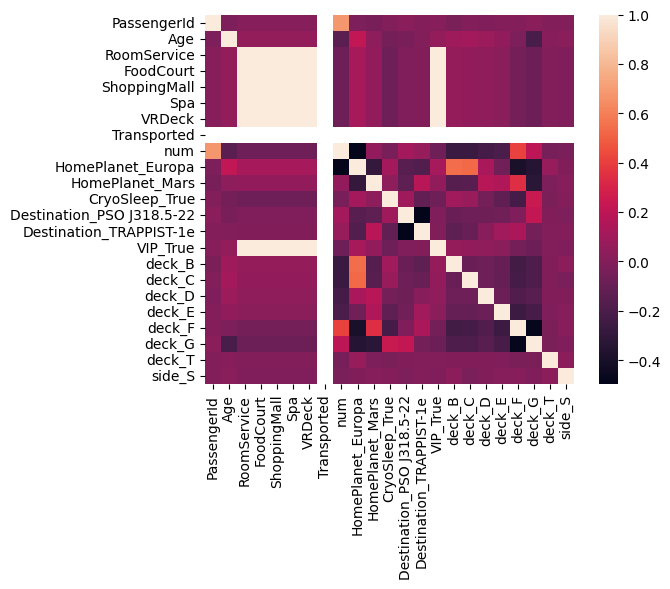

In [21]:
sns.heatmap(df.corr(), square=True)

In [22]:
df.to_csv('processed_titanic.csv', index=False)